# Conteggi e percentuali
In questa sezione verranno presentati alcuni dati generali sulla distribuzione delle lingue per famiglie linguistiche e caratteristiche tipologiche.

In [5]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import info
import loader
import stats
import plotter

dataset_path = "../dataset/features.csv"
    
try:
    df = loader.load_data(dataset_path)
except FileNotFoundError as e:
    print(f"Error: dataset file ({dataset_path}) not found")
    sys.exit(1)

## Distribuzione geografica di alcune famiglie linguistiche

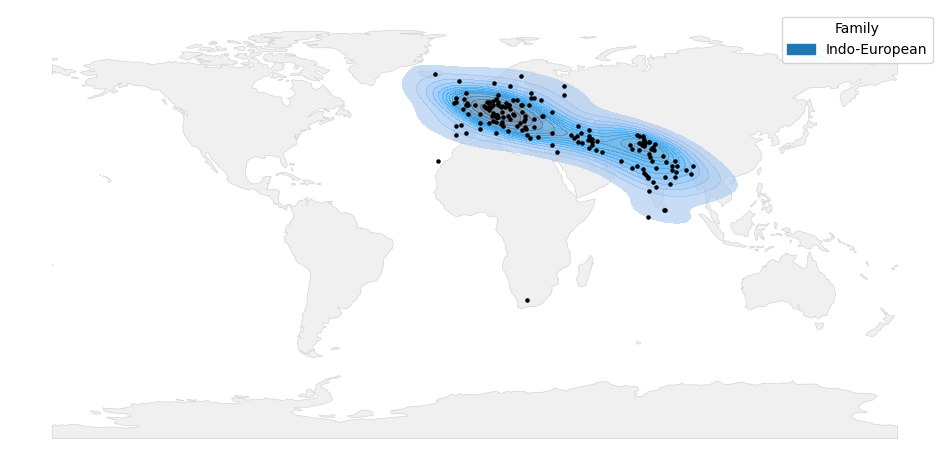

In [6]:
map = stats.map_points(
    df,
    "Family",
    ["Indo-European"]
)

plotter.plot_density_on_map(map, "Family")
plt.show()

## Distribuzione geografica di alcuni valori di parametri

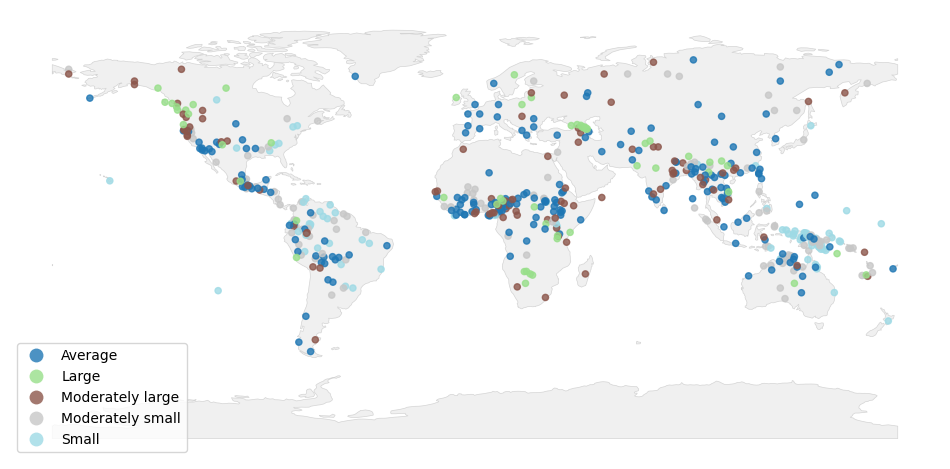

In [7]:
feature_id = "1A"

map = stats.map_points(
    df,
    "Parameter_ID",
    [feature_id]
)

plotter.plot_points_on_map(map, "Code_Name")
plt.show()

## Distribuzione di una feature family-wise

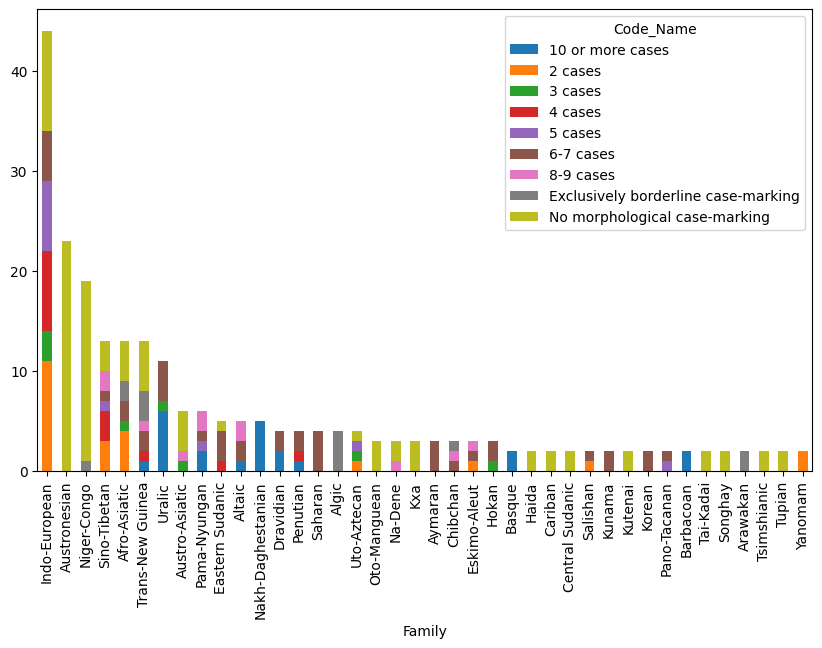

In [13]:
feature_id = "49A"

qdf = df.copy()
qdf = stats.filter(qdf, "Parameter_ID", [feature_id])
qdf = pd.crosstab(qdf["Family"], qdf["Code_Name"])

n_top = 40
qdf = qdf.assign(Total=qdf.sum(axis=1))

qdf = qdf.drop(index="other")

languages_by_family = qdf.sort_values("Total", ascending=False)
languages_by_family = languages_by_family.drop("Total", axis=1)

chunk = stats.get_chunks(languages_by_family, 40)[0]

plotter.stacked_bar_plot(chunk)
